In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import ssl
import certifi

In [8]:
california = fetch_california_housing()
type(california)

sklearn.utils._bunch.Bunch

In [9]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [10]:
print(type(california.data), type(california.target))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [11]:
print(california.data.shape, california.target.shape)

(20640, 8) (20640,)


Объединим массивы в DataFrame

In [12]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [15]:
#Вывод статистики по датасету
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [17]:
#Зададим целевую переменную и факторы
y = data['Price']
X = data.drop('Price', axis=1)

In [19]:
# Выведем форму получившихся массивов
y.shape, X.shape

((20640,), (20640, 8))

Приступим к обучению линейной регрессии

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

MedInc 0.4366932931343251
HouseAge 0.009435778033238192
AveRooms -0.10732204139090433
AveBedrms 0.6450656935198125
Population -3.976389421212774e-06
AveOccup -0.0037865426549709793
Latitude -0.4213143775271436
Longitude -0.43451375467477693


In [22]:
print("Intercept: \n", model.intercept_)

Intercept: 
 -36.94192020718437


Сделаем предсказания модели и выведем на экран первые несколько точек

In [23]:
y_pred = model.predict(X)
print(y_pred[:5])

[4.13164983 3.97660644 3.67657094 3.2415985  2.41358744]


In [24]:
#Для сравнения выведем реальные соответствующие значения целевой переменной
print(y[:5])

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


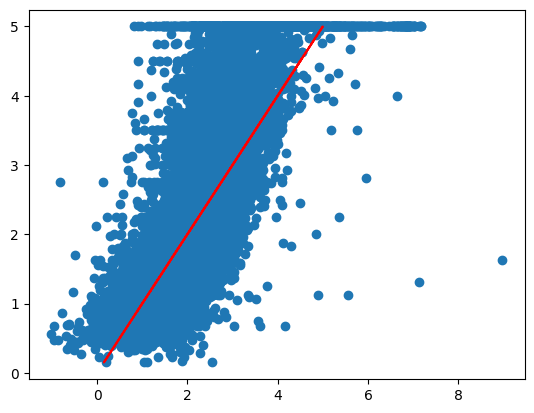

In [25]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

In [26]:
model.score(X, y)

0.606232685199805

Попробуем обучить полиномминальную регрессию

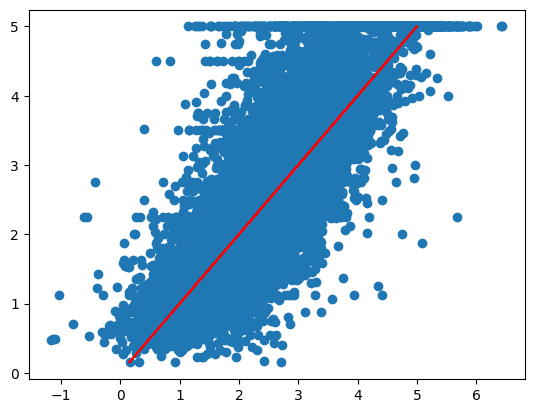

In [45]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(3).fit_transform(X)
polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)
plt.scatter(y_pred_poly, y)
plt.plot(y, y, c='r')

In [46]:
polynomial.score(poly, y)

0.7286583856503401

# Задания для самостоятельного овыполнения

1. Какую еще информацию можно вывести для обученной модели? Попробуйте изменить аргументы при создании модели и посмотрите, как это влияет на качество предсказания.

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2_score(y, y_pred):.4f}")

MSE: 0.5243
RMSE: 0.7241
MAE: 0.5312
R²: 0.6062


In [38]:

# Важность признаков (по абсолютному значению коэффициентов)
coef_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nВажность признаков:")
print(coef_importance)


Важность признаков:
      Feature  Coefficient  Abs_Coefficient
3   AveBedrms     0.645066         0.645066
0      MedInc     0.436693         0.436693
7   Longitude    -0.434514         0.434514
6    Latitude    -0.421314         0.421314
2    AveRooms    -0.107322         0.107322
1    HouseAge     0.009436         0.009436
5    AveOccup    -0.003787         0.003787
4  Population    -0.000004         0.000004


3. Напишите функцию, которая автоматически обучает все перечисленные модели и для каждой выдает оценку точности.

In [47]:
def train_and_evaluate_models(X, y, test_size=0.2, random_state=42):
    """
    Автоматически обучает линейную и полиномиальную регрессию,
    выводит метрики качества для каждой модели.
    
    Parameters:
    -----------
    X : DataFrame или array-like
        Признаки (факторы)
    y : Series или array-like
        Целевая переменная
    test_size : float
        Доля данных для тестовой выборки
    random_state : int
        Фиксация случайности для воспроизводимости
    
    Returns:
    --------
    results : dict
        Словарь с результатами для каждой модели
    """
    
    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    results = {}
    
    # ==================== 1. Линейная регрессия ====================
    print("=" * 60)
    print("1. ЛИНЕЙНАЯ РЕГРЕССИЯ")
    print("=" * 60)
    
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    
    # Предсказания
    y_train_pred = linear_model.predict(X_train)
    y_test_pred = linear_model.predict(X_test)
    
    # Метрики
    linear_metrics = {
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Cross-val R² (5-fold)': cross_val_score(linear_model, X, y, cv=5, scoring='r2').mean()
    }
    
    print(f"Train R²:  {linear_metrics['Train R²']:.4f}")
    print(f"Test R²:   {linear_metrics['Test R²']:.4f}")
    print(f"Test MSE:  {linear_metrics['Test MSE']:.4f}")
    print(f"Test RMSE: {linear_metrics['Test RMSE']:.4f}")
    print(f"Test MAE:  {linear_metrics['Test MAE']:.4f}")
    print(f"CV R²:     {linear_metrics['Cross-val R² (5-fold)']:.4f}")
    
    # Коэффициенты
    print("\nКоэффициенты модели:")
    for feature, coef in zip(X.columns, linear_model.coef_):
        print(f"  {feature}: {coef:.4f}")
    print(f"  Intercept: {linear_model.intercept_:.4f}")
    
    results['Linear Regression'] = {
        'model': linear_model,
        'metrics': linear_metrics
    }
    
    # ==================== 2. Полиномиальная регрессия ====================
    print("\n" + "=" * 60)
    print("2. ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 5)")
    print("=" * 60)
    
    poly = PolynomialFeatures(5)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    
    # Предсказания
    y_train_pred_poly = poly_model.predict(X_train_poly)
    y_test_pred_poly = poly_model.predict(X_test_poly)
    
    # Метрики
    poly_metrics = {
        'Train R²': r2_score(y_train, y_train_pred_poly),
        'Test R²': r2_score(y_test, y_test_pred_poly),
        'Test MSE': mean_squared_error(y_test, y_test_pred_poly),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred_poly)),
        'Test MAE': mean_absolute_error(y_test, y_test_pred_poly),
        'CV R² (5-fold)': cross_val_score(poly_model, X_train_poly, y_train, cv=5, scoring='r2').mean(),
        'Num Features': X_train_poly.shape[1]
    }
    
    print(f"Train R²:  {poly_metrics['Train R²']:.4f}")
    print(f"Test R²:   {poly_metrics['Test R²']:.4f}")
    print(f"Test MSE:  {poly_metrics['Test MSE']:.4f}")
    print(f"Test RMSE: {poly_metrics['Test RMSE']:.4f}")
    print(f"Test MAE:  {poly_metrics['Test MAE']:.4f}")
    print(f"CV R²:     {poly_metrics['CV R² (5-fold)']:.4f}")
    print(f"Признаков: {poly_metrics['Num Features']}")
    
    results['Polynomial Regression'] = {
        'model': poly_model,
        'poly_transformer': poly,
        'metrics': poly_metrics
    }
    
    # ==================== 3. Сравнение моделей ====================
    print("\n" + "=" * 60)
    print("3. СРАВНЕНИЕ МОДЕЛЕЙ")
    print("=" * 60)
    
    comparison = pd.DataFrame({
        'Метрика': ['Train R²', 'Test R²', 'Test RMSE', 'Test MAE', 'CV R²'],
        'Linear': [
            linear_metrics['Train R²'],
            linear_metrics['Test R²'],
            linear_metrics['Test RMSE'],
            linear_metrics['Test MAE'],
            linear_metrics['Cross-val R² (5-fold)']
        ],
        'Polynomial': [
            poly_metrics['Train R²'],
            poly_metrics['Test R²'],
            poly_metrics['Test RMSE'],
            poly_metrics['Test MAE'],
            poly_metrics['CV R² (5-fold)']
        ]
    })
    
    print(comparison.to_string(index=False))
    
    # Рекомендация
    print("\n" + "=" * 60)
    print("РЕКОМЕНДАЦИЯ")
    print("=" * 60)
    
    if linear_metrics['Test R²'] > poly_metrics['Test R²']:
        print("✓ ЛУЧШАЯ МОДЕЛЬ: Линейная регрессия")
        print(f"  Причина: Более высокий Test R² ({linear_metrics['Test R²']:.4f} vs {poly_metrics['Test R²']:.4f})")
        print(f"  Полиномиальная модель переобучается (Train R² >> Test R²)")
    else:
        print("✓ ЛУЧШАЯ МОДЕЛЬ: Полиномиальная регрессия")
        print(f"  Причина: Более высокий Test R² ({poly_metrics['Test R²']:.4f} vs {linear_metrics['Test R²']:.4f})")
    
    return results

In [48]:
results = train_and_evaluate_models(X, y)


1. ЛИНЕЙНАЯ РЕГРЕССИЯ
Train R²:  0.6126
Test R²:   0.5758
Test MSE:  0.5559
Test RMSE: 0.7456
Test MAE:  0.5332
CV R²:     0.5530

Коэффициенты модели:
  MedInc: 0.4487
  HouseAge: 0.0097
  AveRooms: -0.1233
  AveBedrms: 0.7831
  Population: -0.0000
  AveOccup: -0.0035
  Latitude: -0.4198
  Longitude: -0.4337
  Intercept: -37.0233

2. ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 5)
Train R²:  0.3854
Test R²:   -13.6333
Test MSE:  19.1756
Test RMSE: 4.3790
Test MAE:  0.7729
CV R²:     -896847.1155
Признаков: 1287

3. СРАВНЕНИЕ МОДЕЛЕЙ
  Метрика   Linear     Polynomial
 Train R² 0.612551       0.385391
  Test R² 0.575788     -13.633274
Test RMSE 0.745581       4.378992
 Test MAE 0.533200       0.772864
    CV R² 0.553031 -896847.115516

РЕКОМЕНДАЦИЯ
✓ ЛУЧШАЯ МОДЕЛЬ: Линейная регрессия
  Причина: Более высокий Test R² (0.5758 vs -13.6333)
  Полиномиальная модель переобучается (Train R² >> Test R²)


4.Повторите полностью анализ для другого набора данных - встроенного в sklearn датасета diabetes.

In [49]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [50]:
print(f"Тип объекта: {type(diabetes)}")
print(f"Ключи: {diabetes.keys()}")

Тип объекта: <class 'sklearn.utils._bunch.Bunch'>
Ключи: dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [53]:
data = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
data['diabete_progression'] = diabetes.target
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,diabete_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [54]:
y = data['diabete_progression']
X = data.drop('diabete_progression', axis=1)

In [55]:
results = train_and_evaluate_models(X, y)

1. ЛИНЕЙНАЯ РЕГРЕССИЯ
Train R²:  0.5279
Test R²:   0.4526
Test MSE:  2900.1936
Test RMSE: 53.8534
Test MAE:  42.7941
CV R²:     0.4823

Коэффициенты модели:
  age: 37.9040
  sex: -241.9644
  bmi: 542.4288
  bp: 347.7038
  s1: -931.4888
  s2: 518.0623
  s3: 163.4200
  s4: 275.3179
  s5: 736.1989
  s6: 48.6707
  Intercept: 151.3456

2. ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 5)
Train R²:  1.0000
Test R²:   -25.9929
Test MSE:  143012.5868
Test RMSE: 378.1701
Test MAE:  255.9684
CV R²:     -30.7356
Признаков: 3003

3. СРАВНЕНИЕ МОДЕЛЕЙ
  Метрика    Linear  Polynomial
 Train R²  0.527919    1.000000
  Test R²  0.452603  -25.992920
Test RMSE 53.853446  378.170050
 Test MAE 42.794095  255.968358
    CV R²  0.482316  -30.735641

РЕКОМЕНДАЦИЯ
✓ ЛУЧШАЯ МОДЕЛЬ: Линейная регрессия
  Причина: Более высокий Test R² (0.4526 vs -25.9929)
  Полиномиальная модель переобучается (Train R² >> Test R²)
